In [25]:
import akshare as ak
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [35]:
股票代码 = '600000'
start_date = "20241201"
end_date = '20250401'
split_ratio = 0.7
SMA = 15
threshold = 0.5

In [36]:
source_data = ak.stock_zh_a_hist(symbol=股票代码,period="daily",start_date=start_date,end_date=end_date,adjust='')
data = pd.DataFrame()
data['date'] = source_data['日期']
data['price'] = source_data['收盘']
data['volume'] = source_data['成交量']
data['returns']=np.log(data['price']/data['price'].shift(1))
data['returns_cum'] = np.exp(data['returns'].cumsum())
data.set_index('date', inplace=True)
data.dropna();

In [37]:
total_dates = data.index.nunique()
split_index = int(total_dates *split_ratio)
split_date = data.index.unique()[split_index]
train = data[:split_date].copy()
test = data[split_date:].copy()

In [38]:
train['SMA'] = train['price'].rolling(SMA).mean()

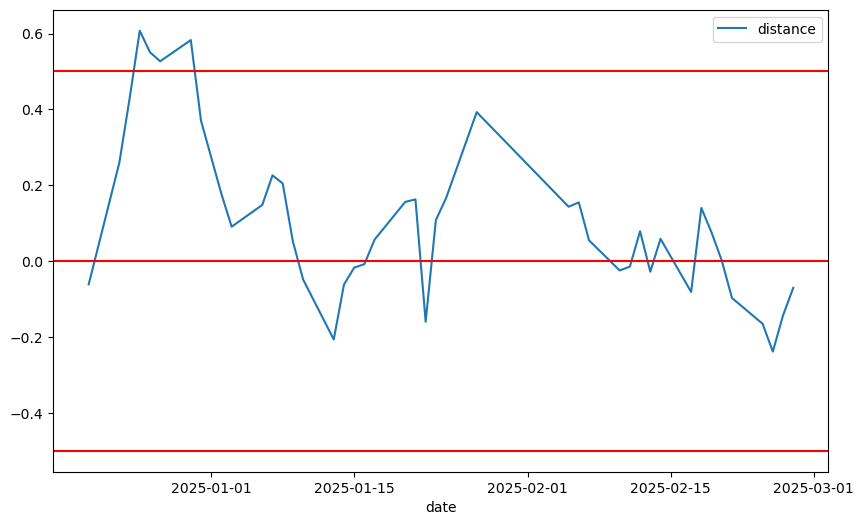

In [39]:
train['distance'] = train['price'] - train['SMA']
train['distance'].dropna().plot(figsize=(10,6), legend=True)
plt.axhline(threshold, color='r')
plt.axhline(-threshold, color='r')
plt.axhline(0, color='r')

In [41]:
train['position'] = np.where(train['distance'] > threshold, -1, np.nan)
train['position'] = np.where(train['distance'] < -threshold, 1, train['position'])
train['position'] = np.where(train['distance'] * train['distance'].shift(1) < 0, 0, train['position'])

In [42]:
train['position'] = train['position'].ffill().fillna(0)

<Axes: xlabel='date'>

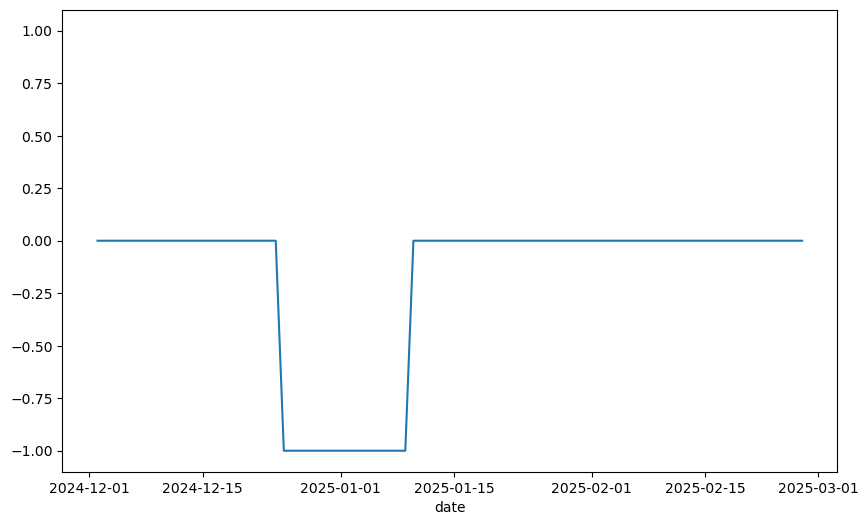

In [45]:
train['position'].plot(ylim=[-1.1,1.1], figsize=(10,6))

In [60]:
def gra_analyze(df):
    df['strategy'] = train['position'].shift(1) * train['returns']

    # Set English fonts and style
    plt.style.use('seaborn-v0_8')
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.unicode_minus'] = False
    
    # ======================
    # 1. Trading Position Plot
    # ======================
    plt.figure(figsize=(25, 3))
    df['position'].plot(ylim=[-1.1, 1.1])
    plt.title('Trading Position (1=Long, -1=Short)')
    plt.ylabel('Position')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 2. Performance Metrics
    # ======================
    metrics = pd.DataFrame()
    
    # Basic statistics
    metrics['Mean'] = df[['returns', 'strategy']].mean()
    metrics['Std Dev'] = df[['returns', 'strategy']].std()
    metrics['Coeff of Variation'] = metrics['Mean'] / metrics['Std Dev']
    metrics['Total Return'] = df[['returns', 'strategy']].sum()
    
    # Calculate max drawdown
    df['cumret'] = df['strategy'].cumsum().apply(np.exp)
    df['cummax'] = df['cumret'].cummax()
    max_drawdown = (df['cummax'] - df['cumret']).max()
    metrics.loc['strategy', 'Max Drawdown'] = max_drawdown
    
    print("Performance Metrics:")
    print(metrics.round(4))
    print(f"\nStrategy Max Drawdown: {max_drawdown:.2%}")
    
    # ======================
    # 3. Price/Volume Plots
    # ======================
    buy = df[df['position'] == 1]
    sell = df[df['position'] == -1]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(25, 12))
    
    # Price plot
    ax1.plot(df['price'], label='Price')
    ax1.scatter(buy.index, buy['price'], color='red', label='Buy Signal')
    ax1.scatter(sell.index, sell['price'], color='green', label='Sell Signal')
    ax1.set_ylabel('Price')
    ax1.legend()
    ax1.grid(True)
    
    # Volume plot
    ax2.bar(buy.index, buy['volume'], color='red', label='Buy Volume')
    ax2.bar(sell.index, sell['volume'], color='green', label='Sell Volume')
    ax2.set_ylabel('Volume')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle('Price and Volume with Trading Signals', y=0.92)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 4. Cumulative Returns
    # ======================
    plt.figure(figsize=(25, 8))
    df[['cumret', 'cummax']].plot()
    plt.title('Cumulative Returns vs Peak Returns')
    plt.ylabel('Returns')
    plt.legend(['Cumulative Returns', 'Peak Returns'])
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ======================
    # 5. Strategy Comparison
    # ======================
    plt.figure(figsize=(25, 12))
    
    df['passive_cumret'] = df['returns'].cumsum().apply(np.exp)
    df['auto_strategy_cumret'] = df['strategy'].cumsum().apply(np.exp)
    
    ax1 = plt.gca()
    ax2 = ax1.twinx()
    
    # Passive investment
    ax2.plot(df['passive_cumret'], 
            label='Passive Investment', 
            color='#FF6B00',
            linewidth=4,
            alpha=0.8,
            zorder=3)
    
    # Dynamic strategy
    ax2.plot(df['auto_strategy_cumret'], 
            label='Dynamic Strategy', 
            color='#E51937',
            linewidth=3,
            linestyle='--',
            zorder=2)
    
    '''
    # MA strategies
    colors = plt.cm.Greys(np.linspace(0.3, 0.7, 22))
    for days in range(1, 23):
        ax2.plot(df[f'sty_cumr_{days}d'], 
                 color=colors[days-1],
                 alpha=0.4,
                 linewidth=1,
                 zorder=1)
    '''
                 
    '''
    # Best MA strategy
    strategy_performance = {}
    for days in range(1, 23):
        final_return = df[f'sty_cumr_{days}d'].iloc[-1]
        strategy_performance[days] = final_return
    top_strategy = max(strategy_performance.items(), key=lambda x: x[1])
    
    days, return_value = top_strategy
    ax2.plot(df[f'sty_cumr_{days}d'], 
             label=f'Best MA Strategy: {days}D (Return:{return_value-1:.1%})',
             color='#1F77B4',
             alpha=0.8,
             linewidth=3,
             zorder=2)
    '''
             
    '''
    # Trading zones
    ax1.fill_between(df.index, 
                    df['price'].min()*0.98, 
                    df['price'].max()*1.02,
                    where=(df['auto_strategy_mean_return']==1),
                    color='green', alpha=0.05, label='Long Zone')
    ax1.fill_between(df.index,
                     df['price'].min()*0.98,
                     df['price'].max()*1.02,
                     where=(df['auto_strategy_mean_return']==-1),
                     color='red', alpha=0.05, label='Short Zone')
    
    ax1.set_ylabel('Price')
    ax2.set_ylabel('Cumulative Returns')
    ax1.tick_params(axis='y', colors='black')
    ax2.tick_params(axis='y', colors='blue')
    
    plt.title('Strategy Performance Comparison', pad=20)
    ax1.grid(True, linestyle='--', alpha=0.3)
    '''
     
    # Legend handling
    handles, labels = [], []
    for ax in [ax1, ax2]:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in labels:
                handles.append(h)
                labels.append(l)
    plt.legend(handles, labels, loc='upper left', ncol=3)
    
    # Performance annotations
    max_passive = df['passive_cumret'].max()
    max_strategy = df['auto_strategy_cumret'].max()
    plt.annotate(f'Passive Max: {max_passive-1:.1%}',
                xy=(df['passive_cumret'].idxmax(), max_passive),
                xytext=(15, 15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'))
    plt.annotate(f'Strategy Max: {max_strategy-1:.1%}',
                xy=(df['auto_strategy_cumret'].idxmax(), max_strategy),
                xytext=(-60, 15), textcoords='offset points',
                arrowprops=dict(arrowstyle='->'))
    
    plt.tight_layout()
    plt.show()
    
    return metrics

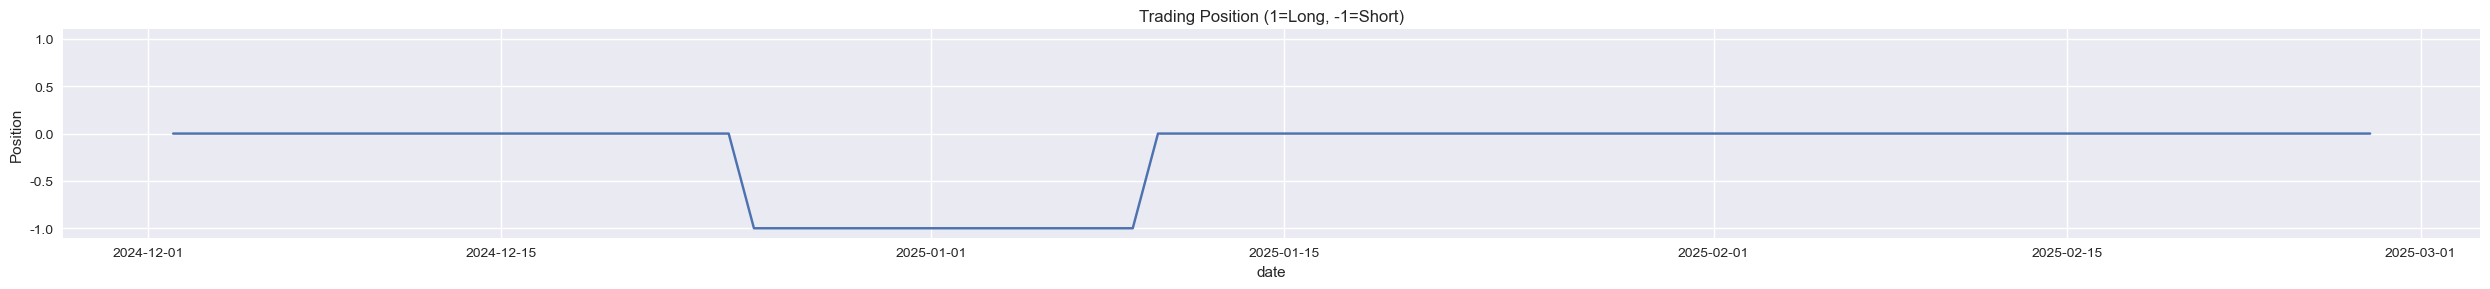

Performance Metrics:
            Mean  Std Dev  Coeff of Variation  Total Return  Max Drawdown
returns   0.0014   0.0136              0.0998        0.0761           NaN
strategy  0.0004   0.0044              0.0866        0.0215         0.024

Strategy Max Drawdown: 2.40%


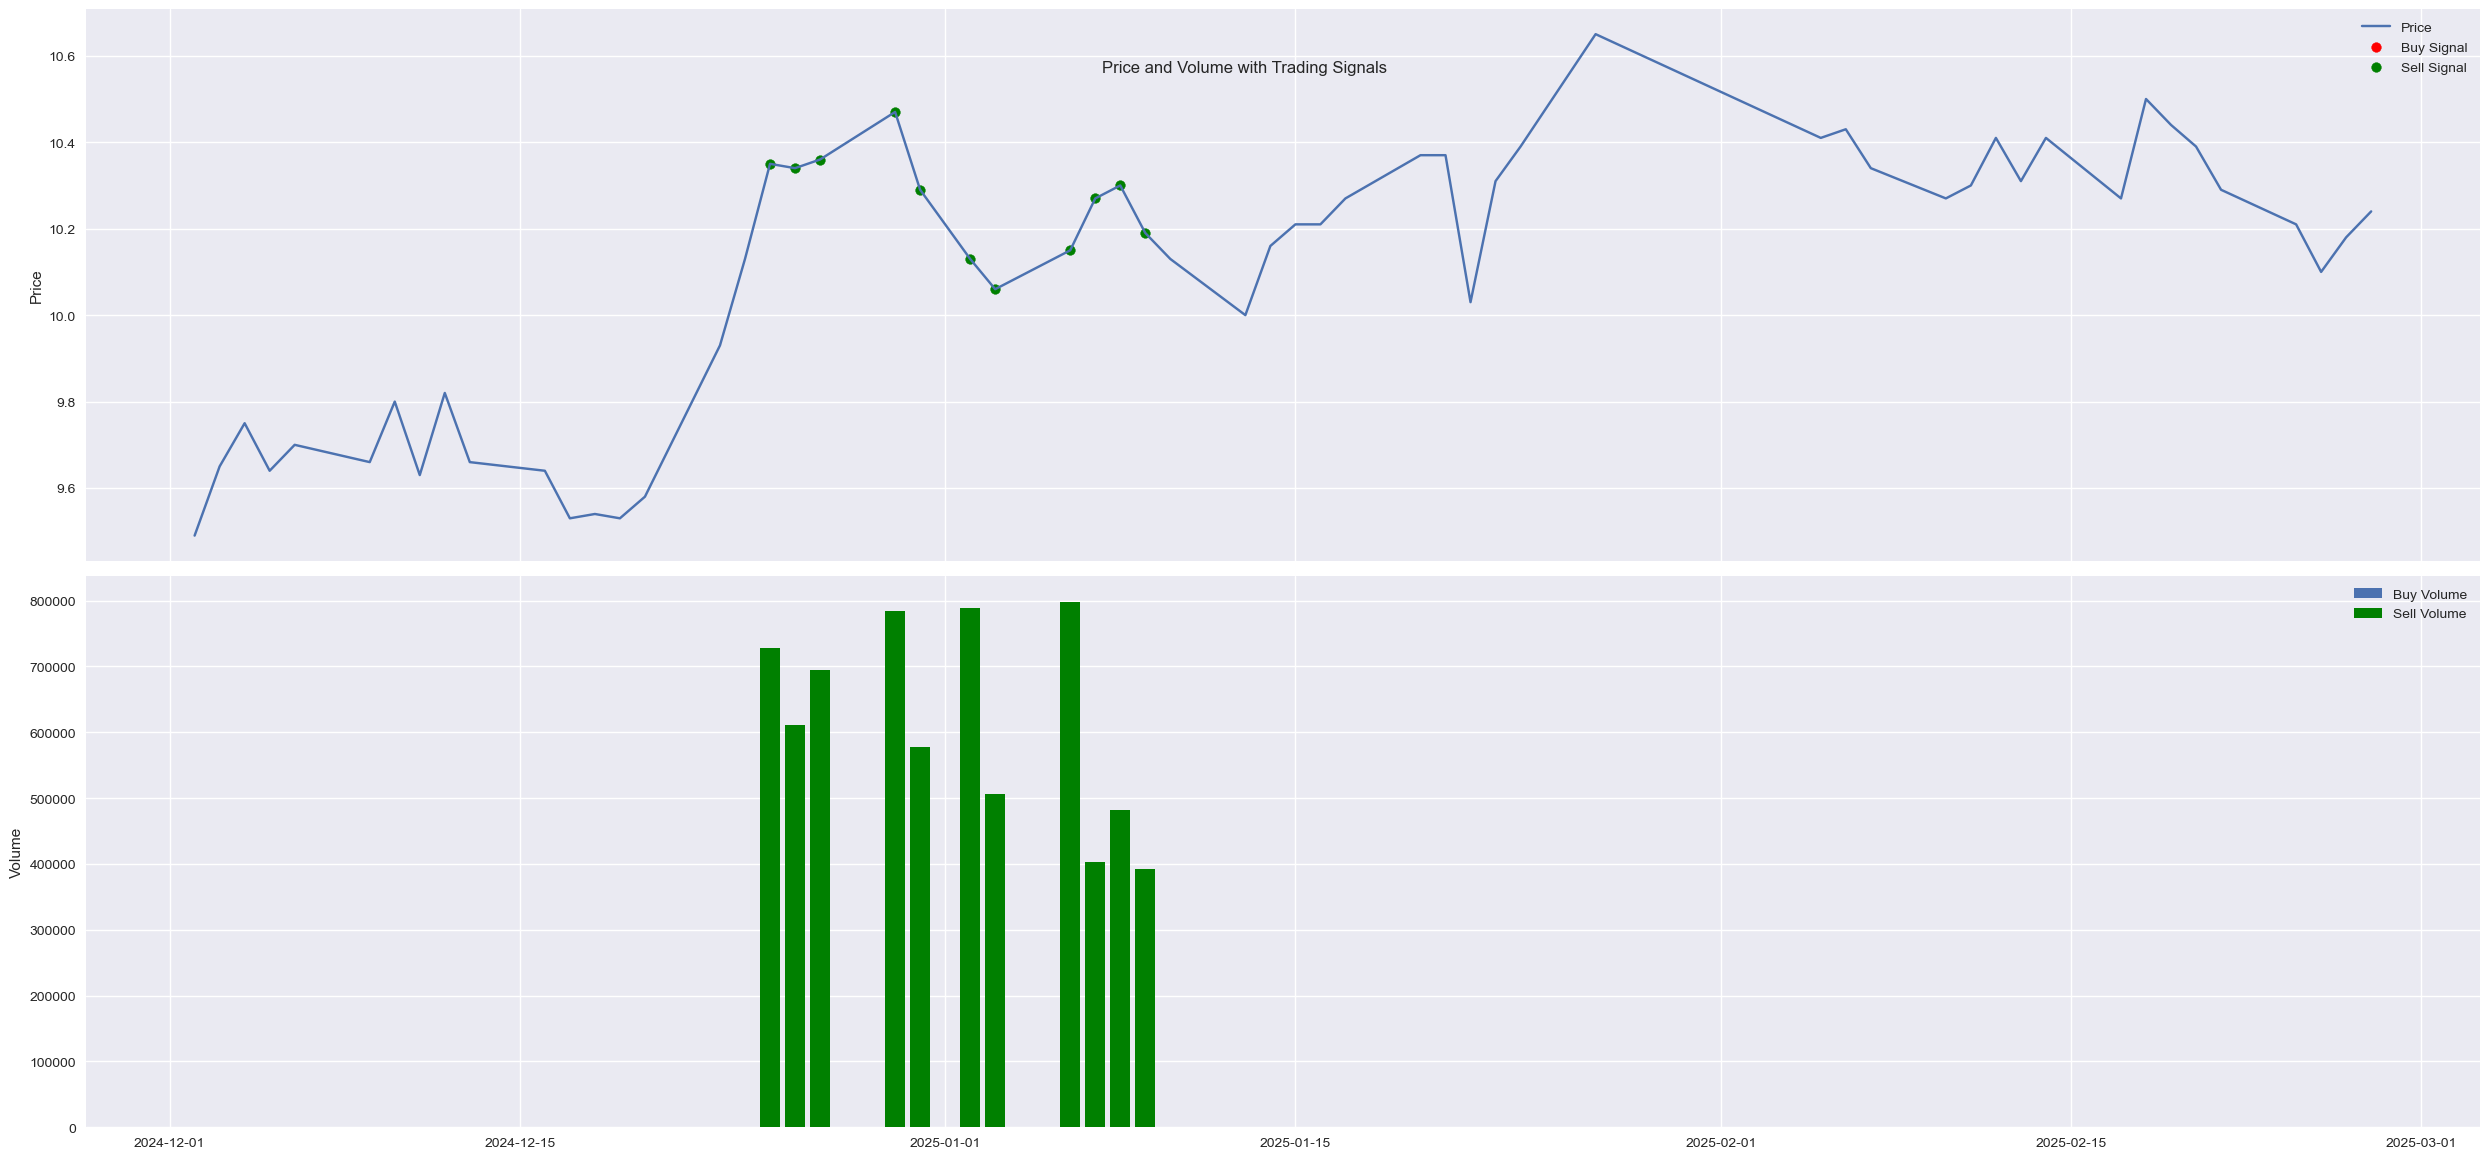

<Figure size 2500x800 with 0 Axes>

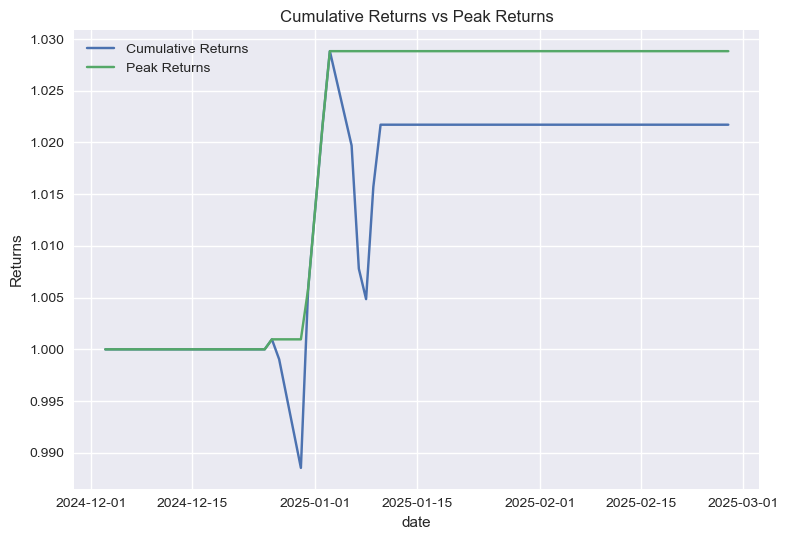

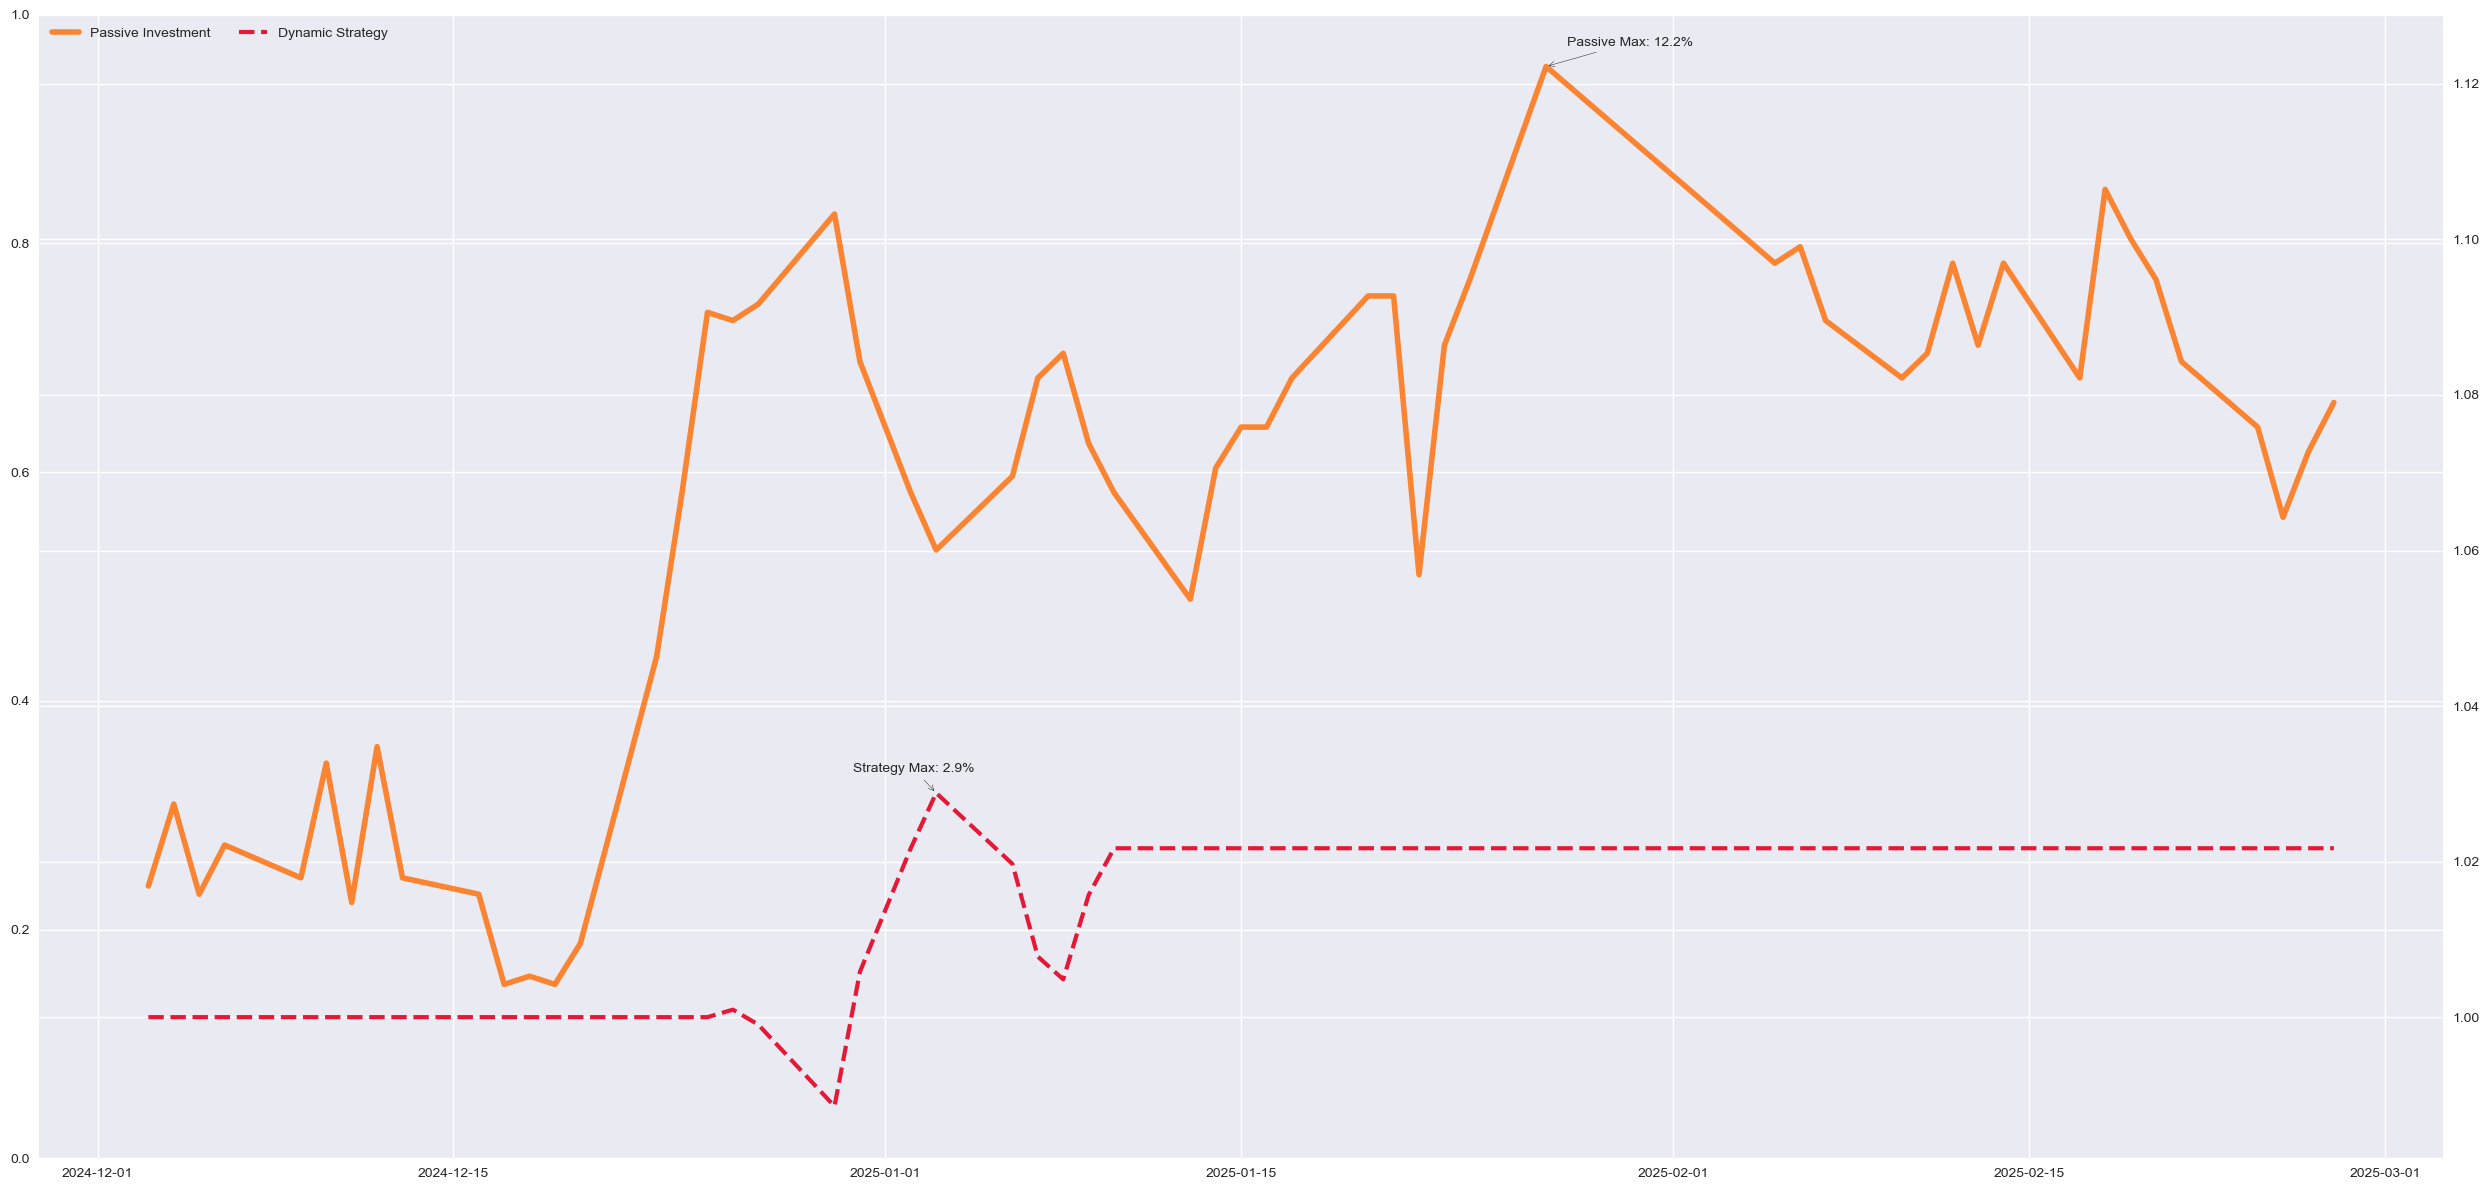

,Mean,Std Dev,Coeff of Variation,Total Return,Max Drawdown
returns,0.001358,0.013613,0.099776,0.076063,NaN
strategy,0.000384,0.004428,0.086641,0.021485,0.023973


In [61]:
gra_analyze(train)